# Implementing Quantum Tangent Kernel (QTK) with Qiskit

This notebook implements the Quantum Tangent Kernel (QTK) based on the paper *Quantum Tangent Kernel* (arXiv:2111.02951v2), using Qiskit's modern primitives API. We extract gradient-based quantum features and use them with an SVM.

# What are Kernels?

In machine learning, a **kernel** is a function that measures similarity between two data points. Instead of working in the original input space, kernels allow us to **implicitly project data into a higher-dimensional feature space**, where linear methods like SVMs can perform complex, nonlinear classification.

The key idea:

$K(x_i, x_j) = \langle \phi(x_i), \phi(x_j) \rangle = \phi(x_i)^T \phi(x_j)$

Here, $\phi(x)$ is the (possibly infinite-dimensional) feature map. The kernel function $K$ computes the inner product **as if** the data were transformed into this high-dimensional space - **without ever actually performing the expensive transformation**. This is called the **kernel trick**.

Mapping to higher dimensions helps because many datasets are **not linearly separable** in the original space. But when lifted into a higher-dimensional space:

- Complex, nonlinear patterns often become **linearly separable**
- A simple classifier (like an SVM) can now draw a hyperplane to separate classes that were entangled in the original space
- Kernels provide the benefits of richer representations without the computational cost of working in high-dimensional space directly

# Neural Tangent Kernel (NTK):

The **Neural Tangent Kernel (NTK)** is a special kind of kernel that arises when analyzing deep neural networks in the **infinite-width limit $(Width \ w \to \infty )$**.

In the **infinite-width limit**, training a neural network using gradient descent is equivalent to:
- Performing **kernel regression** using the NTK
- No need to train layers — the network behaves like a **linear model in a high-dimensional feature space**

NTK defines the kernel based on the **gradients of the model output with respect to its parameters**:

$K_{\text{NTK}}(x_i, x_j) = \nabla_{\theta} f(x_i, \theta)^T \cdot \nabla_{\theta} f(x_j, \theta)$

- $f(x,\theta)$: the neural network’s output
- $\nabla_\theta f$: how sensitive that output is to the model parameters $\theta$

This gradient becomes the feature map and $K_{\text{NTK}}(x_i, x_j)$ is a measure of similarity between two inputs $x_i$ and $x_j$, based on how similarly they affect the output of a neural network through its parameters $\theta$.

- If the gradients of $f(x_i,\theta)$ and $f(x_j,\theta)$ are similar (i.e., they push the model output in the same direction), $K_{NTK}$ is large.
- If the gradients of $f(x_i,\theta)$ and $f(x_j,\theta)$ are orthogonal or opposed (i.e., they push the model output in opposite directions), $K_{NTK}$ is small or negative.

# Imports
This cell loads required modules for quantum circuit construction, gradient evaluation, and classical SVM classification. We use Qiskit Primitives (Estimator) and Qiskit Algorithms (ParamShiftEstimatorGradient).

In [1]:
import time
import warnings
import numpy as np
from tqdm.auto import tqdm
from sklearn.svm import SVC
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.circuit import Parameter
from qiskit.primitives import Estimator
from qiskit.quantum_info import SparsePauliOp
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, mean_squared_error
from qiskit_algorithms.gradients import ParamShiftEstimatorGradient

warnings.simplefilter('ignore', category=DeprecationWarning)

## Breakdown of the Quantum Model:

The authors apply the NTK formula to parameterized quantum circuits, by using the following model:

$y(x, \theta) = \langle 0^n | U^\dagger(x, \theta)\, O\, U(x, \theta) | 0^n \rangle$ as described in Eq. (16) of the paper.

- $| 0^n \rangle$ : This is the initial quantum state of $n$ qubits, all set to 0.

- $x$ = input data

- $\theta$ = parameters of the quantum circuit

- $U(x, \theta)$ : The parameterized quantum circuit. It transforms the initial state.

- $O$: An observable, typically a Pauli operator (like  $Z$, $X$, or combinations) used to measure the transformed circuit.

- $U^\dagger(x, \theta)$: The Hermitian conjugate (or inverse) of the unitary $U(x, \theta)$. It reverses the transformation made by $U(x, \theta)$ and returns the circuit back to the original ground state, for measuring the observable.

- $\langle 0^n | \cdots | 0^n \rangle $: This gives the expectation value.

- $y(x, \theta)$ = The output of the model = The expectation of the observable $O$.

## Define Observable using Qiskit Primitives
We define a Pauli Z observable acting on a chosen qubit using `SparsePauliOp`. This observable is used in the circuit expectation value as described in Eq. (16) of the paper.

In [2]:
# Define function to create a Pauli-Z observable on a specific qubit (qubit_index) out of a total number of qubits (total_qubits)
def create_observable_z(qubit_index, total_qubits):
    """
    Create a Pauli-Z observable on a specific qubit.
    Args:
        qubit_index (int): The index of the qubit to apply the Pauli-Z operator.
        total_qubits (int): The total number of qubits in the system.
    Returns:
        SparsePauliOp: The Pauli-Z observable as a SparsePauliOp.
    """

    # Initialize a list of 'I' (identity operators) for all qubits
    z_string = ['I'] * total_qubits

    # Set the 'Z' (Pauli-Z operator) for the specified qubit
    z_string[qubit_index] = 'Z'

    # Convert the list of operators into a single string representing the operator
    pauli_str = ''.join(z_string)

    # Return the observable as a SparsePauliOp with no scaling (coefficient=1.0)
    return SparsePauliOp.from_list([(pauli_str, 1.0)])

## Build Deep QTK Circuit

The authors define a "Deep" QTK using the following ansatz: $U_{\text{deep}}(x, \theta) = \prod_{i=1}^{L} \left[ V(\theta_i) U_{\phi}(x) \right]$

This deep ansatz, described in Equation 19 in the paper, contains $L$ layers with each layer performing the following operations in sequence:

- $U_\phi (x)$ = The quantum feature map to encode the data into the quantum circuit
- $V(\theta_i)$ = A parameterized unitary operation built from rotation gates and entanglement, where the angles are tunable parameters. It allows the quantum circuit to learn the patterns in the data.

The authors define $U_\phi (x)$ using the following equation (Equation 20 in the paper):

$U_{\phi}(x) = \exp\left( i \sum_{S \subseteq [m]} \phi_S(x) \bigotimes_{i \in S} Y_i \right)$

- $[m] = \{ 1, 2, \dots, m \}$ — the set of qubit indices (for 4 qubits,  $[4] = \{ 1, 2, 3, 4 \}$ )
- $S \subseteq [m]$ = all possible $2^m$ subsets of those indices.
    - In the paper, $[m]$ is truncated to $\{ 1, 2 \}$. i.e. $S$ only consists of either all single qubit terms, or, two-qubit interaction terms.
    - Higher-order subsets are are too expensive to simulate or build.
- $\phi_S(x)$: Defines how the data $x$ affects the rotation angle.
    - $\phi_i(x) = \arcsin(x_i) \rightarrow$ For 1-qubit terms
    - $\phi_{ij}(x) = \arcsin(x_i \cdot x_j) \rightarrow$ For 2-qubit interaction terms
- $\bigotimes_{i \in S} Y_i$ = apply a Pauli-Y operator on qubits in set $S$.
    - if $S = \{a\}$, it gives $Y_a$. i.e. Pauli Y operator is applied on the qubit at index $a$. Identity to the other qubits.
    - if $S = \{a,b\}$, it gives $Y_a \bigotimes Y_b$. Pauli Y operator is applied on the qubits at indices $\{a,b\}$, and then tensor product.
- Each term in the sum is of the form: $\phi_S(x) \cdot \left( Y_i \otimes Y_j \otimes \dots \right)$ for $S = \{ i, j \}$
- Mathematically, $U_\phi (x)$ is building a sum of Pauli Y-strings, each weighted by some function \phi_S(x), and then exponentiating the whole thing.
- Thus, $U_\phi (x)$ is a data-weighted linear combination of Pauli-Y terms, giving us a quantum encoding for classical data $x$

The authors define $V(\theta_i) \in SU(4)$ using Cartan decomposition in Equation 24:

$V(\theta_i) = k_1 \cdot \exp\left( 2i \left( \theta_{xx} X \otimes X + \theta_{yy} Y \otimes Y + \theta_{zz} Z \otimes Z \right) \right) \cdot k_2$

- $SU(4)$ = the group of all possible 2-qubit unitaries 
    - 4×4 matrices with determinant 1
    - requires 15 real quantum parameters
    - computationally expensive on both quantum hardware as well as classical simulation
- $k_1, k_2 \in SU(2) \otimes SU(2)$ = Local (non-entangling) unitary operations acting on each qubit
- $\exp\left( 2i \left( \theta_{xx} X \otimes X + \theta_{yy} Y \otimes Y + \theta_{zz} Z \otimes Z \right) \right)$
    - The entangling component of the SU(4) unitary
    - Applies interaction between qubits via the Pauli tensor products:
    - $X \otimes X$: flips both qubits
    - $Y \otimes Y$: flips with phase
    - $Z \otimes Z$: parity interaction

We use a hardware-efficient ansatz (RY + RZ + CX) instead of full SU(4) blocks because SU(4) decomposition is computationally expensive and requires deeper circuits. The hardware-efficient ansatz offers a practical trade-off: it is easy to implement, differentiable, and expressive enough to capture useful gradients for QTK, while being compatible with near-term quantum hardware and simulators.

We implement the following hardware efficient ansatz as $V(\theta)$:

$V(\theta) = \bigotimes_{i=0}^{n-1} \left[ RZ(\theta_{2i+1}) \cdot RY(\theta_{2i}) \right] \cdot \text{Entangle}$

- $\theta_{2i}$ and $\theta_{2i+1}$ are trainable parameters assigned to qubit $i$
- $RY(\theta) = \exp\left( -i \frac{\theta}{2} Y \right)$
- $RZ(\phi) = \exp\left( -i \frac{\phi}{2} Z \right)$
- CNOTs introduce entanglement between adjacent qubits to capture correlations between qubits

In [3]:
# Create a parameterized quantum circuit
def create_qtk_param_circuit(x, param_list, num_layers, num_qubits):
    """
    Create a quantum circuit for the QTK (Quantum Kernel) model.
    Args:
        x (array-like): Input data point to be encoded into the quantum circuit.
        param_list (list): List of parameters for the parameterized gates in the circuit.
        num_layers (int): Number of QTK layers in the circuit.
        num_qubits (int): Number of qubits in the quantum circuit.
    Returns:
        QuantumCircuit: The constructed quantum circuit.
    """
    # Create a quantum circuit with the specified number of qubits
    qc = QuantumCircuit(num_qubits)

    # Initialize index to track parameter usage from param_list
    idx = 0

    # Loop over the "L" QTK layers
    for l in range(num_layers):
        
        # ----- Data encoding block: U_phi(x) -----
        for i in range(num_qubits):  # Apply RY gates with input encoding
            qc.ry(2 * np.arcsin(x[i]), i)  # Single-qubit feature map: RY(2 * arcsin(x_i))

        for i in range(num_qubits - 1):  # Apply CRY gates for two-qubit encoding
            qc.cry(2 * np.arcsin(x[i] * x[i + 1]), i, i + 1)  # Two-qubit feature interaction: CRY(2 * arcsin(x_i * x_{i+1}))

        # ----- Parameterized unitary block: V(theta) -----
        for i in range(num_qubits):  # Apply trainable RY and RZ rotations
            qc.ry(param_list[idx], i)  # Parameterized RY rotation
            idx += 1
            qc.rz(param_list[idx], i)  # Parameterized RZ rotation
            idx += 1

        for i in range(num_qubits - 1):  # Add entanglement via CX gates
            qc.cx(i, i + 1)  # CNOT between adjacent qubits

    return qc  # Return the complete circuit representing U_deep(x, theta)

## Compute QTK Feature Vectors

The authors define the quantum tangent kernel in Equation 17 in the paper as follows:

$K_{\text{qtk}}(x_i, x_j) = \phi(x_i)^T \phi(x_j) = \nabla_{\theta} y(x_i, \theta_0)^T \nabla_{\theta} y(x_j, \theta_0)$

$\phi(x_i) = \nabla_{\theta} y(x, \theta)$ is the gradient of the model output with respect to the parameters, i.e., the QTK feature vector for input $x$

Using Equation 16, we can rewrite $\nabla_{\theta} y(x, \theta)$ as follows:

$\nabla_{\theta} y(x, \theta) = \nabla_{\theta} \langle 0^n | U^\dagger(x, \theta) O U(x, \theta) | 0^n \rangle$

We compute $\nabla_\theta y(x, \theta)$ using Qiskit's parameter-shift rule.

In [4]:
# Define function to compute QTK feature vector
def compute_qtk_feature_vector(x, param_matrix):
    """
    Compute the QTK feature vector for a given input x and parameter matrix.
    Args:
        x (array-like): Input data point.
        param_matrix (numpy.ndarray): Matrix of parameters for the QTK circuit.
    Returns:
        numpy.ndarray: QTK feature vector.
    """

    # Extract number of layers and parameters per layer
    num_layers, num_params = param_matrix.shape

    # Set number of qubits = dimension of input x
    num_qubits = len(x)

    param_list = [Parameter(f'theta_{l}_{i}')                     # Create a list of symbolic parameters for the circuit,
                  for l in range(num_layers)                      # formatted as theta_layer_index
                  for i in range(num_params)]

    # Build the deep QTK circuit with x and param_list
    qc = create_qtk_param_circuit(x, param_list, num_layers, num_qubits)

    # Create a Qiskit estimator to measure expectation values of observables
    estimator = Estimator()

    # Wrap the estimator with gradient computation using parameter-shift
    # Computes the gradient of the expectation value with respect to circuit parameters via the parameter-shift rule.
    grad = ParamShiftEstimatorGradient(estimator)

    # Define Z observable acting on qubit 3 (can be changed)
    observable = create_observable_z(3, num_qubits)

    result = grad.run(                                            # Run the gradient computation
        circuits=[qc],                                            # Circuit to differentiate
        observables=[observable],                                 # Observable to measure expectation value
        parameter_values=[param_matrix.flatten().tolist()],       # Numerical values for each symbolic parameter
        parameters=[param_list]                                   # List of parameters to differentiate with respect to
    ).result()                                                    # Get the result (blocks until finished)

    # Return the gradient (QTK feature vector) as a NumPy array
    return np.array(result.gradients[0])

## Generate Synthetic Data and Features
The authors use ansatz generated synthetic data:
- Input Data $(x)$:
    - Each input is a 4 dimensional real-valued vector that is randomly generated i.e $x_i \in \mathbb{R}^4$
    - The values are randomly generated
    - Total 15,000 samples. (10k for training and 5k for testing)
- Quantum Circuit:
    - Uses the deep QTK ansatz defined previously
    - 4 qubits and 10 layers
- Label $(y)$ Generation:
    - For each sample $(x_i)$, compute the folllowing expectation:
    - $l(x_i, \theta) = \langle 0^n | U_{\text{deep}}^\dagger(x_i, \theta) Z_4 U_{\text{deep}}(x_i, \theta) | 0^n \rangle$
    - $\theta% here is randomly chosen
- Labels:
    - $y_i = 1 \quad \text{if} \quad l(x_i, \theta) \geq 0$
    - $y_i = -1 \quad \text{if} \quad l(x_i, \theta) < 0$

In [5]:
def compute_label_expectation(x_i, param_matrix, num_qubits, num_layers):
    """
    Compute the expectation value l(x_i, θ) = <0^n | U_deep† Z U_deep | 0^n> using raw numeric parameters.

    Args:
        x_i (ndarray): Input data vector (length = num_qubits).
        param_matrix (ndarray): Numeric parameter matrix of shape (num_layers, 2 * num_qubits).
        num_qubits (int): Number of qubits.
        num_layers (int): Number of circuit layers.

    Returns:
        float: Expectation value of Pauli-Z on qubit 3.
    """
    # Flatten the param_matrix into a list of gate parameters
    param_list = param_matrix.flatten().tolist()  # shape (num_layers * 2 * num_qubits,)

    # Build the circuit using raw values (not Parameters)
    qc = create_qtk_param_circuit(x_i, param_list, num_layers, num_qubits)

    # Add measurement to all qubits
    qc.measure_all()

    # Simulate
    simulator = AerSimulator()
    result = simulator.run(qc, shots=1024).result()
    counts = result.get_counts()

    # Compute Z expectation value on qubit 3
    z_index = 3
    expectation = 0

    for bitstring, count in counts.items():
        bit = int(bitstring[-1 - z_index])        # bitstring is ordered left-to-right (MSB to LSB)
        z_val = 1 if bit == 0 else -1             # Z|0⟩ = +1, Z|1⟩ = -1
        expectation += z_val * count

    return expectation / 1024.0

In [6]:
def generate_synthetic_dataset(n_samples=500, num_qubits=4, num_layers=10, seed=42):
    """
    Generate a synthetic dataset using the Deep QTK Ansatz.

    Args:
        n_samples (int): Number of input data samples to generate.
        num_qubits (int): Number of qubits (i.e., input dimension).
        num_layers (int): Number of layers in the QTK circuit.
        seed (int): Random seed for reproducibility.

    Returns:
        features_train (ndarray): QTK feature vectors for training set.
        features_test (ndarray): QTK feature vectors for test set.
        y_train (ndarray): Labels for training set.
        y_test (ndarray): Labels for test set.
        param_matrix (ndarray): The parameter matrix (shared across all samples).
    """
    np.random.seed(seed)

    # 1. Generate Random Input Data (Shape: n_samples × num_qubits)
    X = np.random.rand(n_samples, num_qubits)

    # 2. Initialize Shared Parameter Matrix (Same for Feature Map & Labeling)
    param_matrix = np.random.uniform(0, 2*np.pi, size=(num_layers, 2 * num_qubits))

    # 3. Compute QTK Features
    features = np.array([
        compute_qtk_feature_vector(x, param_matrix) 
        for x in tqdm(X, desc=f"Computing QTK features. Depth = {num_layers}")
    ])

    # 4. Generate Labels from Deep QTK Circuit
    y = np.zeros(n_samples)
    for i in tqdm(range(n_samples), desc=f"Computing labels. Depth = {num_layers}"):
        l_value = compute_label_expectation(X[i], param_matrix, num_qubits, num_layers)
        y[i] = 1 if l_value > 0 else -1

    # 5. Train-Test Split
    features_train, features_test, y_train, y_test = train_test_split(
        features, y, test_size=0.2, random_state=seed
    )

    return features_train, features_test, y_train, y_test, param_matrix

## QTK Kernel Matrix and Train SVM
We construct the kernel matrix $K(x_i, x_j) = \phi(x_i) \phi(x_j)^T$ and use it to train an SVM, completing the deep QTK classification pipeline as implemented by the authors in Section 4 of the paper.

In [7]:
layer_range = [3, 5, 10, 20, 50]
train_accuracies = []
test_accuracies = []
train_mse = []
test_mse = []
timings = []

for L in tqdm(layer_range, desc="Evaluating different depths"):
    start_time = time.time()

    features_train, features_test, y_train, y_test, _ = generate_synthetic_dataset(
        n_samples=100, num_qubits=4, num_layers=L, seed=42
    )
    # Log the time taken to generate the dataset
    dataset_time = time.time() - start_time

    K_train = features_train @ features_train.T
    K_test = features_test @ features_train.T

    svm = SVC(kernel='precomputed', C=0.01*L)
    svm.fit(K_train, y_train)

    y_train_pred = svm.predict(K_train)
    y_test_pred = svm.predict(K_test)

    timings.append(dataset_time)
    train_accuracies.append(accuracy_score(y_train, y_train_pred))
    test_accuracies.append(accuracy_score(y_test, y_test_pred))
    train_mse.append(mean_squared_error(y_train, y_train_pred))
    test_mse.append(mean_squared_error(y_test, y_test_pred))

Evaluating different depths:   0%|          | 0/5 [00:00<?, ?it/s]

Computing QTK features. Depth = 3:   0%|          | 0/100 [00:00<?, ?it/s]

Computing labels. Depth = 3:   0%|          | 0/100 [00:00<?, ?it/s]

Computing QTK features. Depth = 5:   0%|          | 0/100 [00:00<?, ?it/s]

Computing labels. Depth = 5:   0%|          | 0/100 [00:00<?, ?it/s]

...

Computing labels. Depth = 10:   0%|          | 0/100 [00:00<?, ?it/s]

Computing QTK features. Depth = 20:   0%|          | 0/100 [00:00<?, ?it/s]

Computing labels. Depth = 20:   0%|          | 0/100 [00:00<?, ?it/s]

Computing QTK features. Depth = 50:   0%|          | 0/100 [00:00<?, ?it/s]

Computing labels. Depth = 50:   0%|          | 0/100 [00:00<?, ?it/s]

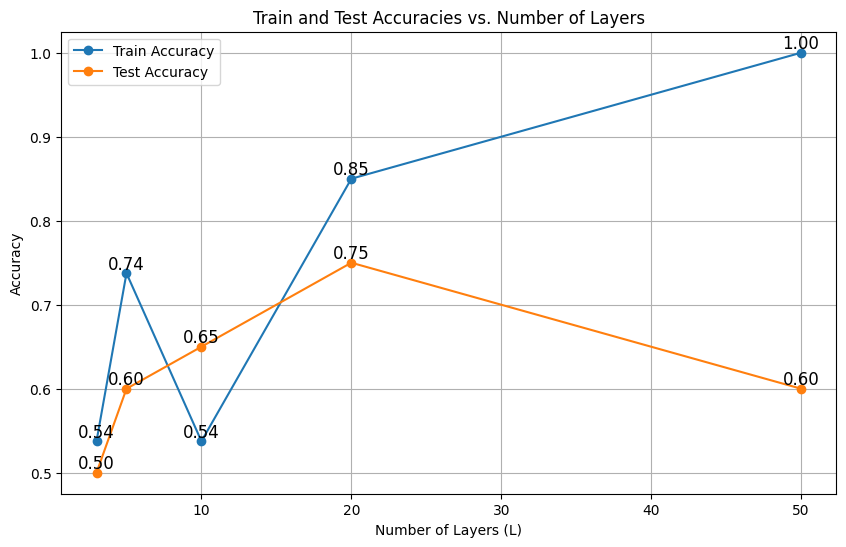

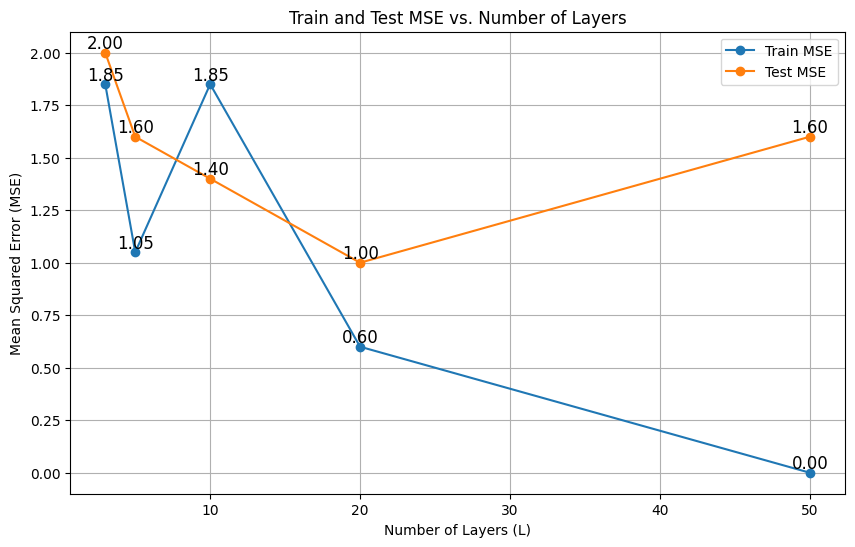

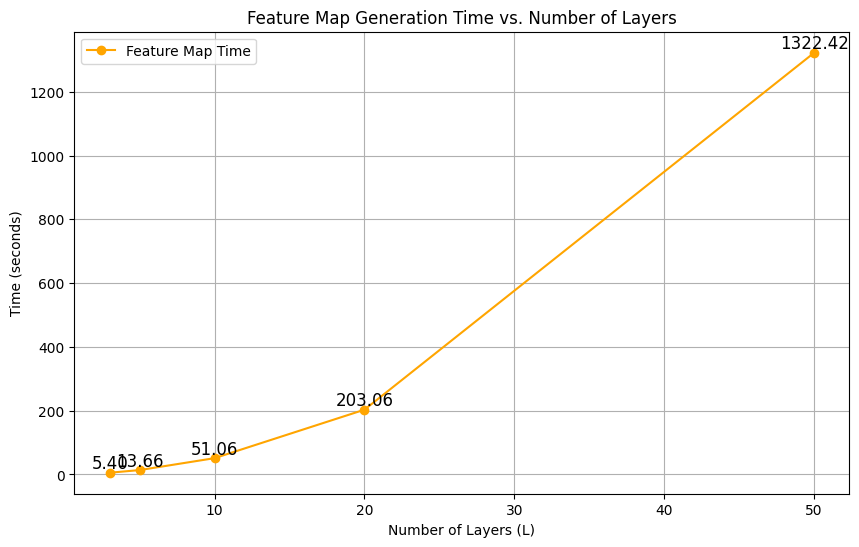

In [18]:
# Plot training and test accuracies
plt.figure(figsize=(10, 6))
plt.plot(layer_range, train_accuracies, label="Train Accuracy", marker="o")
plt.plot(layer_range, test_accuracies, label="Test Accuracy", marker="o")
for i, (x, y) in enumerate(zip(layer_range, train_accuracies)):
    plt.text(x, y, f"{y:.2f}", fontsize=12, ha='center', va='bottom')
for i, (x, y) in enumerate(zip(layer_range, test_accuracies)):
    plt.text(x, y, f"{y:.2f}", fontsize=12, ha='center', va='bottom')
plt.xlabel("Number of Layers (L)")
plt.ylabel("Accuracy")
plt.title("Train and Test Accuracies vs. Number of Layers")
plt.legend()
plt.grid(True)
plt.savefig("train_test_accuracy.png", dpi=300)
plt.show()

# Plot training and test MSE
plt.figure(figsize=(10, 6))
plt.plot(layer_range, train_mse, label="Train MSE", marker="o")
plt.plot(layer_range, test_mse, label="Test MSE", marker="o")
for i, (x, y) in enumerate(zip(layer_range, train_mse)):
    plt.text(x, y, f"{y:.2f}", fontsize=12, ha='center', va='bottom')
for i, (x, y) in enumerate(zip(layer_range, test_mse)):
    plt.text(x, y, f"{y:.2f}", fontsize=12, ha='center', va='bottom')
plt.xlabel("Number of Layers (L)")
plt.ylabel("Mean Squared Error (MSE)")
plt.title("Train and Test MSE vs. Number of Layers")
plt.legend()
plt.grid(True)
plt.savefig("train_test_mse.png", dpi=300)
plt.show()

# Plot time taken to generate datasets
plt.figure(figsize=(10, 6))
plt.plot(layer_range, timings, label="Feature Map Time", marker="o", color="orange")
for i, (x, y) in enumerate(zip(layer_range, timings)):
    plt.text(x, y, f"{y:.2f}", fontsize=12, ha='center', va='bottom')
plt.xlabel("Number of Layers (L)")
plt.ylabel("Time (seconds)")
plt.title("Feature Map Generation Time vs. Number of Layers")
plt.legend()
plt.grid(True)
plt.savefig("feature_map_time.png", dpi=300)
plt.show()

In [9]:
train_accuracies

[0.5375, 0.7375, 0.5375, 0.85, 1.0]

In [10]:
test_accuracies

[0.5, 0.6, 0.65, 0.75, 0.6]

In [11]:
train_mse

[1.85, 1.05, 1.85, 0.6, 0.0]

In [12]:
test_mse

[2.0, 1.6, 1.4, 1.0, 1.6]

In [13]:
timings

[5.396663665771484,
 13.655928134918213,
 51.06262278556824,
 203.0554940700531,
 1322.420155763626]